# Data Overview, EDA, and Text Based Statistical Features

# Install and Import Library

In [ ]:
!pip install tensorflow -q
!pip install imbalanced-learn -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from sklearn.utils import class_weight

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version : 2.20.0
GPU Available      : 0


# Load Dataset

In [ ]:
df = pd.read_csv('mental_health.csv')

# Exploring Data

The dataset consists of statements tagged with one of the following seven mental health statuses:

*   Normal
*   Depression
*   Suicidal
*   Anxiety
*   Stress
*   Bi-Polar
*   Personality Disorder

Personality Disorder
The data is sourced from diverse platforms including social media posts, Reddit posts, Twitter posts, and more.

In [ ]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
df.describe()

,Unnamed: 0
count,53043.000000
mean,26521.000000
std,15312.339501
min,0.000000
25%,13260.500000
50%,26521.000000
75%,39781.500000
max,53042.000000


# Explatory Data Analysis

In [ ]:
df = df[['statement', 'status']]
df.reset_index(drop=True, inplace = True)

In [ ]:
df.shape
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


Data Cleaning (Check and Remove Null Value)

In [ ]:
df.isnull().sum()

,0
statement,362
status,0


In [ ]:
df.dropna(inplace = True)
df.isnull().sum()

,0
statement,0
status,0


In [ ]:
print(df['status'].value_counts())

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


Check Class Imbalance

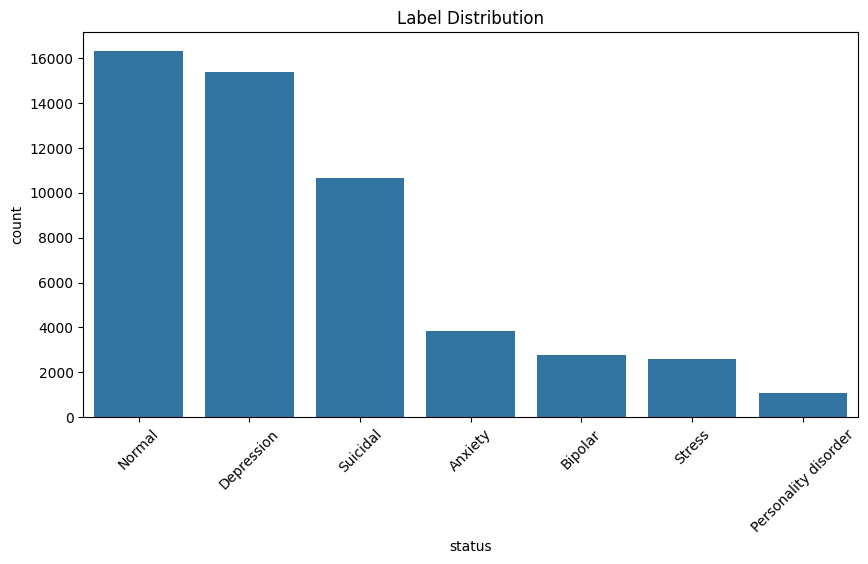

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['status'], order=df['status'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Label Distribution")
plt.show()

In [ ]:
df.describe()

,statement,status
count,52681,52681
unique,51073,7
top,what do you mean?,Normal
freq,22,16343


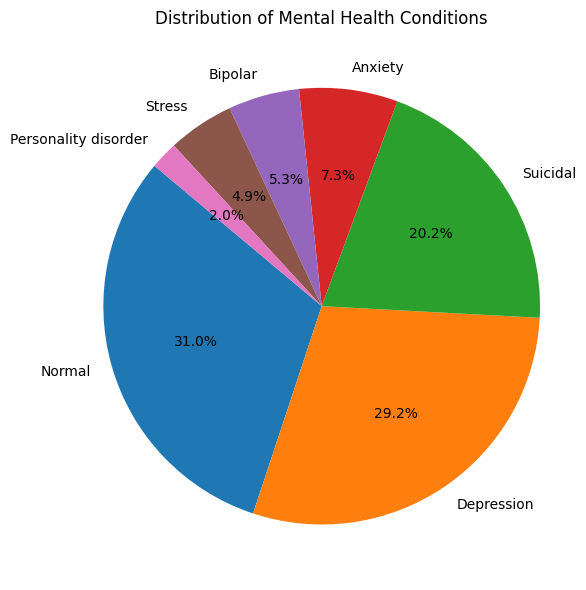

In [ ]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)

plt.title('Distribution of Mental Health Conditions')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
df[df['statement']== 'what do you mean?']

,statement,status
31098,what do you mean?,Normal
31216,what do you mean?,Normal
31377,what do you mean?,Normal
31522,what do you mean?,Normal
31606,what do you mean?,Normal
31675,what do you mean?,Normal
31788,what do you mean?,Normal
31882,what do you mean?,Normal
31981,what do you mean?,Normal
32022,what do you mean?,Normal


Looking Raw Texts

In [ ]:
random_statements = df.groupby('status')['statement'].apply(lambda x: x.sample(n=1).iloc[0])

for status, statement in random_statements.items():
    print(f"Status: {status}")
    print(f"Statement: {statement}\n")

Status: Anxiety
Statement: Keep getting twitches all around my body For a few days now I keep getting these twitches around my body, usually in my legs. I can't feel any weakness but I'm fairly sure it won't be long before my mind starts tricking me into believing I can. I'm pretty worried it might be something serious like MD or ALS, what are the odds of that?

Status: Bipolar
Statement: Is it a trick of depression to not care about getting better? I just don’t care. I used to want to get better, but right now I don’t care. I could just eat and sleep and drink beer and read books and that’s it. Go on forever, never seeing friends, never accomplishing anything.

Is this a trick, or am I just fucked up and weird?

Status: Depression
Statement: depression anxiety lack of sleep lack of new yukika music lack of weed http t co d y 9 zpry

Status: Normal
Statement: Memories Panga

Status: Personality disorder
Statement: Entitled People I had a guy cut in front of me and another woman at the 

# Text Based Statistical Features

In [ ]:
df['char_count'] = df['statement'].apply(len)
df['word_count'] = df['statement'].apply(lambda x: len(x.split()))
df['unique_words'] = df['statement'].apply(lambda x: len(set(x.split())))
df['lexical_diversity'] = df['unique_words'] / df['word_count']

num_features = ['char_count', 'word_count', 'unique_words', 'lexical_diversity']

/tmp/ipykernel_1191/183971440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='status', y=feature, palette='viridis')


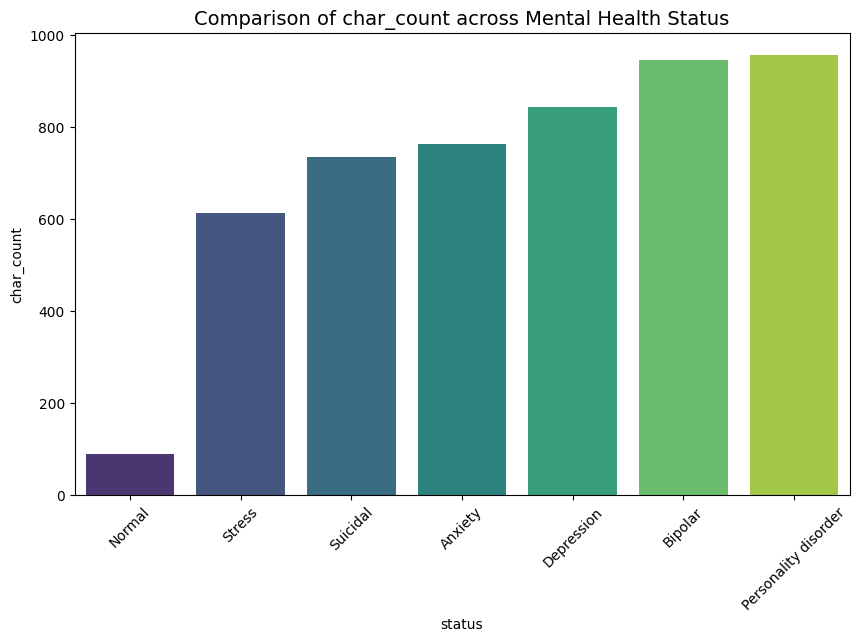

/tmp/ipykernel_1191/183971440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='status', y=feature, palette='viridis')


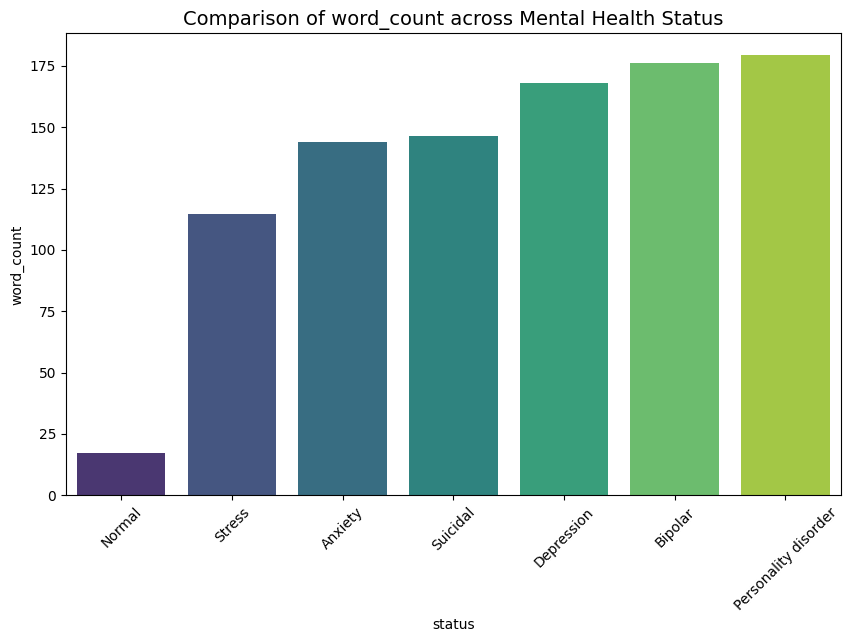

/tmp/ipykernel_1191/183971440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='status', y=feature, palette='viridis')


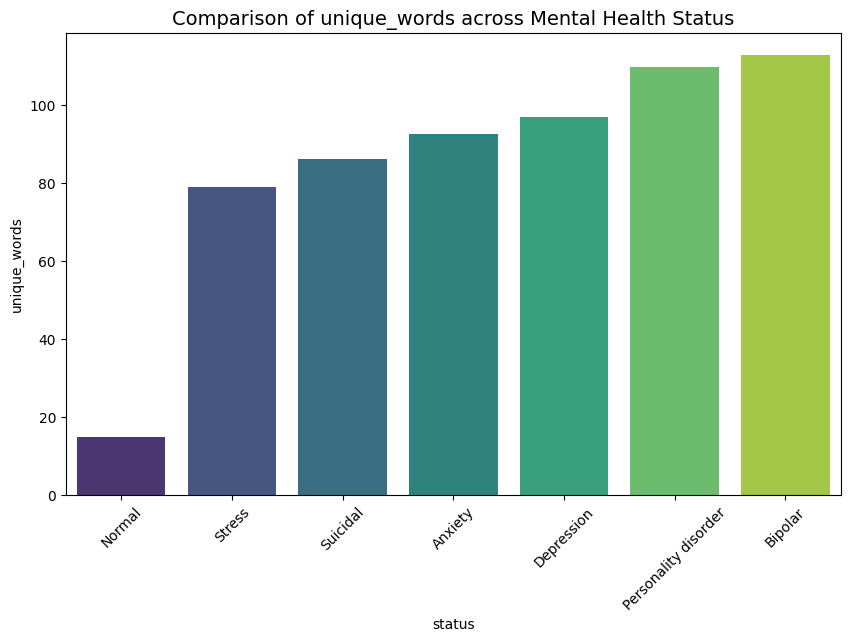

/tmp/ipykernel_1191/183971440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='status', y=feature, palette='viridis')


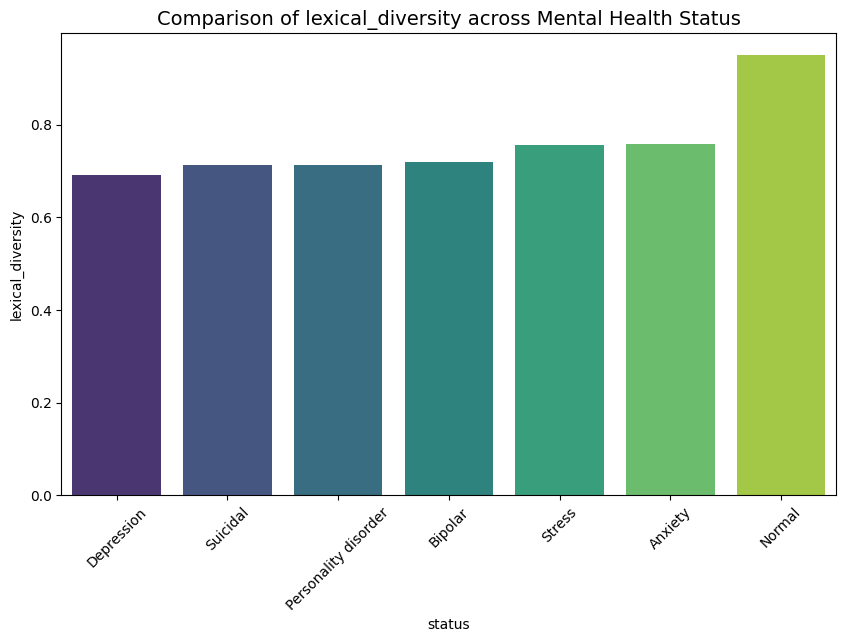

In [ ]:
for feature in num_features:
    plt.figure(figsize=(10, 6))
    plot_data = df.groupby('status')[feature].mean().sort_values().reset_index()
    sns.barplot(data=plot_data, x='status', y=feature, palette='viridis')
    plt.title(f'Comparison of {feature} across Mental Health Status', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

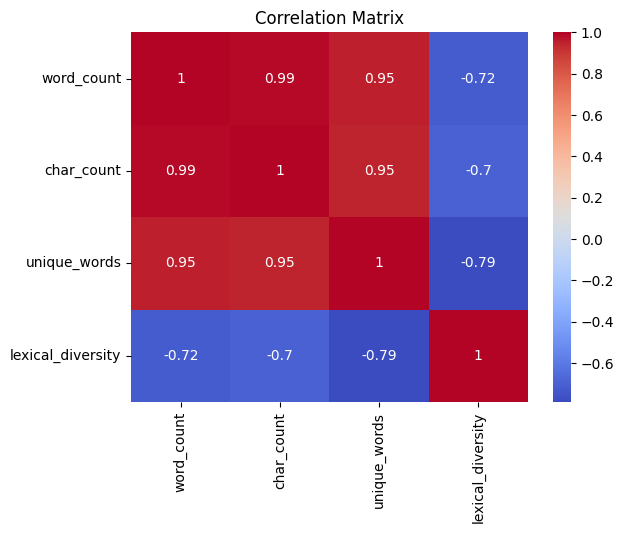

In [ ]:
corr = df[['word_count','char_count','unique_words','lexical_diversity']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Top Words

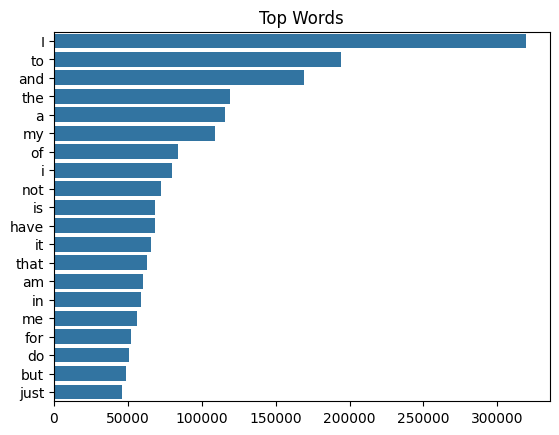

In [ ]:
from collections import Counter

def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

top_words = get_top_words(df['statement'], 20)

words, counts = zip(*top_words)

sns.barplot(x=list(counts), y=list(words))
plt.title("Top Words")
plt.show()

# Model 1: LSTM Baseline + RandomUnderSampler

# Install and Import Library

In [ ]:
!pip install tensorflow -q
!pip install imbalanced-learn -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version : 2.20.0
GPU Available      : 1


# Load Dataset and Data Preprocessing

In [ ]:
df = pd.read_csv('mental_health.csv')

In [ ]:
df = df[['statement', 'status']]
df.reset_index(drop=True, inplace=True)

In [ ]:
df.dropna(inplace=True)
print(df['status'].value_counts())

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


Data Preprocessing

In [ ]:
def clean_text_lstm(text):
    # 1. Ubah ke huruf kecil
    text = str(text).lower()

    # 2. Hapus Unicode / Emoji / Karakter Rusak (seperti ðŸ’ª)
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 3. Hapus URL, Mention (@), dan Hashtag (#)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # 4. Hapus karakter Enter / Newline
    text = re.sub(r"[\n\r]", " ", text)

    # 5. Hapus angka (Angka jarang relevan untuk sentimen mental health)
    text = re.sub(r"\d+", " ", text)

    # 6. Hapus SEMUA tanda baca, sisakan HANYA huruf a-z dan spasi
    text = re.sub(r"[^a-z\s]", " ", text)

    # 7. Rapikan spasi yang berlebihan
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['processed_text'] = df['statement'].apply(clean_text_lstm)

In [ ]:
df

,statement,status,processed_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,i ve shifted my focus to something else but i ...
4,"I'm restless and restless, it's been a month n...",Anxiety,i m restless and restless it s been a month no...
...,...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,nobody takes me seriously ive m dealt with dep...
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety,selfishness i don t feel very good it s like i...
53040,Is there any way to sleep better? I can't slee...,Anxiety,is there any way to sleep better i can t sleep...
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety,public speaking tips hi all i have to give a p...


# Label Encoding

In [ ]:
label_map = {k:i for i,k in enumerate(df['status'].value_counts().index)}
reverse_label_map = {v: k for k, v in label_map.items()}
num_classes = len(label_map)

df['label'] = df['status'].map(label_map)
print("\nLabel Map:", label_map)


Label Map: {'Normal': 0, 'Depression': 1, 'Suicidal': 2, 'Anxiety': 3, 'Bipolar': 4, 'Stress': 5, 'Personality disorder': 6}


# Data Split

In [ ]:
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    df['processed_text'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Handle Imbalance (Random Under Sampler)

In [ ]:
print("\nApplying Random Undersampling on Training Data...")
rus = RandomUnderSampler(random_state=42)

# Reshape X_train_raw untuk imblearn
X_train_resampled, y_train_resampled = rus.fit_resample(
    X_train_raw.values.reshape(-1, 1), y_train_raw
)

# Kembalikan ke format Pandas Series
X_train = pd.Series(X_train_resampled.flatten())
y_train = pd.Series(y_train_resampled)

print("\nDistribusi Train setelah Undersampling:\n", y_train.value_counts())


Applying Random Undersampling on Training Data...

Distribusi Train setelah Undersampling:
 label
0    862
1    862
2    862
3    862
4    862
5    862
6    862
Name: count, dtype: int64


# Tokenization

In [ ]:
MAX_VOCAB = 10000
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 20

print("\nTokenizing Text Data...")
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_valid_seq = pad_sequences(tokenizer.texts_to_sequences(X_valid), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')


Tokenizing Text Data...


# Custom Focal Loss Class

In [ ]:
class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes, gamma=2.0, alpha=0.25, from_logits=False):
        super().__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_onehot = tf.one_hot(y_true, depth=self.num_classes)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1 - y_pred, self.gamma)
        loss = weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

# Model 1: Baseline LSTM + Random Under Sampling

In [ ]:
print("\nBuilding LSTM Model...")
model_lstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

focal_loss = SparseCategoricalFocalLoss(num_classes=num_classes, gamma=2.0, alpha=0.25, from_logits=False)

model_lstm.compile(optimizer='adam', loss=focal_loss, metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1)


Building LSTM Model...


Training

In [ ]:
print("\nStarting Training Model 1 (LSTM)...\n")
history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    validation_data=(X_valid_seq, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr]
)


Starting Training Model 1 (LSTM)...

Epoch 1/20
189/189 [==============================] - 92s 445ms/step - loss: 0.2966 - accuracy: 0.3043 - val_loss: 0.2245 - val_accuracy: 0.4945 - lr: 0.0010
Epoch 2/20
189/189 [==============================] - 70s 370ms/step - loss: 0.2052 - accuracy: 0.4475 - val_loss: 0.1943 - val_accuracy: 0.5114 - lr: 0.0010
Epoch 3/20
189/189 [==============================] - 58s 306ms/step - loss: 0.1481 - accuracy: 0.5630 - val_loss: 0.1735 - val_accuracy: 0.5784 - lr: 0.0010
Epoch 4/20
189/189 [==============================] - 58s 307ms/step - loss: 0.1088 - accuracy: 0.6627 - val_loss: 0.1618 - val_accuracy: 0.5926 - lr: 0.0010
Epoch 5/20
189/189 [==============================] - ETA: 0s - loss: 0.0812 - accuracy: 0.7355
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
189/189 [==============================] - 57s 301ms/step - loss: 0.0812 - accuracy: 0.7355 - val_loss: 0.1788 - val_accuracy: 0.6080 - lr: 0.0010
Epoch 6/20


# Evaluasi Model 1: Baseline LSTM + Random Undersampling


Evaluating Model...

165/165 [==============================] - 5s 30ms/step

Model 1 Classification Report:

                      precision    recall  f1-score   support

              Normal       0.90      0.82      0.86      1635
          Depression       0.62      0.41      0.49      1541
            Suicidal       0.56      0.67      0.61      1066
             Anxiety       0.62      0.32      0.42       384
             Bipolar       0.39      0.48      0.43       278
              Stress       0.25      0.58      0.35       258
Personality disorder       0.19      0.64      0.30       107

            accuracy                           0.60      5269
           macro avg       0.51      0.56      0.49      5269
        weighted avg       0.66      0.60      0.61      5269



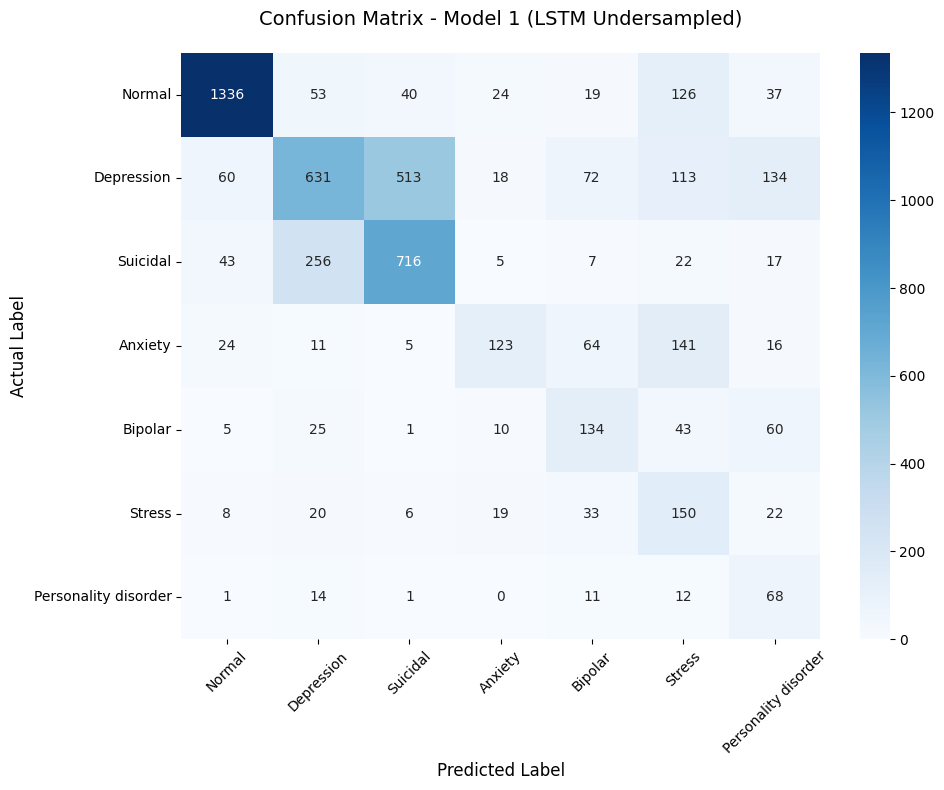

In [ ]:
print("\nEvaluating Model...\n")
y_pred1_probs = model_lstm.predict(X_test_seq)
y_pred1 = np.argmax(y_pred1_probs, axis=1)

print("\nModel 1 Classification Report:\n")
print(classification_report(y_test, y_pred1, target_names=label_map.keys()))

cm1 = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_map.keys(),
    yticklabels=label_map.keys()
)

plt.title('Confusion Matrix - Model 1 (LSTM Undersampled)', pad=20, fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualisasi Training History

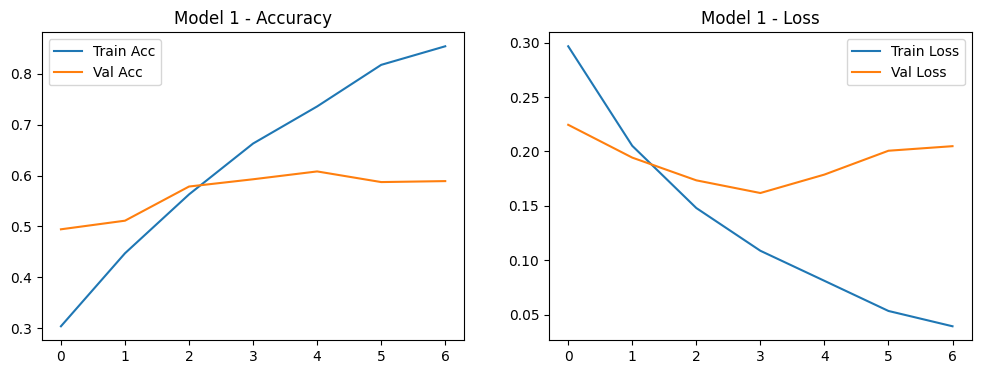

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.title("Model 1 - Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("Model 1 - Loss")
plt.legend()
plt.show()

# Predict Function Model 1 Baseline LSTM + Random Undersampling

In [ ]:
def predict_model_1(text):
    # 1. Bersihkan teks
    text_processed = clean_text_lstm(text)

    # 2. Ubah teks menjadi angka (Tokenization) dan samakan panjangnya (Padding)
    seq = tokenizer.texts_to_sequences([text_processed])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    # 3. Minta Model 1 untuk menebak
    pred = model_lstm.predict(pad, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    # 4. Cetak Hasilnya
    print("Input Text      :", text)
    print("Predicted Label :", reverse_label_map[pred_class])
    print(f"Confidence Score: {confidence:.4f}")
    print("-" * 40)

print("\n--- Uji Coba Prediksi Model 1 ---")
predict_model_1("I feel empty and hopeless everyday")
predict_model_1("Today I am happy and excited")
predict_model_1("I'm constantly worrying about the future and can't breathe")


--- Uji Coba Prediksi Model 1 ---
Input Text      : I feel empty and hopeless everyday
Predicted Label : Normal
Confidence Score: 0.4745
----------------------------------------
Input Text      : Today I am happy and excited
Predicted Label : Suicidal
Confidence Score: 0.4136
----------------------------------------
Input Text      : I'm constantly worrying about the future and can't breathe
Predicted Label : Anxiety
Confidence Score: 0.5497
----------------------------------------


# Model 2 RoBERTa (MentalBERT) + Random Under Sampling

# Install and Environment Setup

In [ ]:
!pip uninstall -y transformers -q
!pip install transformers==4.38.2 -q
!pip install tensorflow -q
!pip install imbalanced-learn -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", len(tf.config.list_physical_devices('GPU')))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 25.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
TensorFlow Version : 2.20.0
GPU Available      : 1


# Load Dataset and Data Cleaning

In [ ]:
df = pd.read_csv("mental_health.csv")
df = df[['statement', 'status']].dropna().reset_index(drop=True)

print("Dataset Shape (Original):", df.shape)

def clean_text_bert(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['processed_text'] = df['statement'].apply(clean_text_bert)

# Hapus teks yang terlalu pendek (< 4 kata) karena ambigu
df = df[df['processed_text'].str.split().str.len() > 3]
df = df.reset_index(drop=True)

Dataset Shape (Original): (52681, 2)


# Label Encoding

In [ ]:
label_map = {label: idx for idx, label in enumerate(df['status'].unique())}
reverse_label_map = {idx: label for label, idx in label_map.items()}
num_classes = len(label_map)

df['label'] = df['status'].map(label_map)

print("\nLabel Mapping:")
print(label_map)


Label Mapping:
{'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}


# Train Valid Test Split

In [ ]:
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Random Undersampling

In [ ]:
print("\nApplying Random Undersampling on Training Data...")
rus = RandomUnderSampler(random_state=42)

X_train_resampled, y_train_resampled = rus.fit_resample(
    X_train_raw.values.reshape(-1, 1),
    y_train_raw
)

X_train = pd.Series(X_train_resampled.flatten())
y_train = pd.Series(y_train_resampled)

print("\nTrain Size (After Undersampling) :", len(X_train))
print("Valid Size                       :", len(X_valid))
print("Test Size                        :", len(X_test))


Applying Random Undersampling on Training Data...

Train Size (After Undersampling) : 6034
Valid Size                       : 5082
Test Size                        : 5083


# Hugging Face

In [ ]:
!pip install huggingface_hub -q
from huggingface_hub import login

login(token="______")

# Tokenization Mental Bert

In [ ]:
MODEL_NAME = "mental/mental-bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 4

print(f"\nLoading Tokenizer : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='tf'
    )

train_encodings = encode_data(X_train)
valid_encodings = encode_data(X_valid)
test_encodings  = encode_data(X_test)


Loading Tokenizer : mental/mental-bert-base-uncased


# TF Dataset

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask']},
    y_train.values
)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': valid_encodings['input_ids'], 'attention_mask': valid_encodings['attention_mask']},
    y_valid.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask']},
    y_test.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build Mental Bert Model

In [ ]:
print(f"\nLoading Pretrained Model : {MODEL_NAME}")
model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes, from_pt=True)

model.config.hidden_dropout_prob = 0.3
model.config.attention_probs_dropout_prob = 0.3


Loading Pretrained Model : mental/mental-bert-base-uncased


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Custom Focal Loss

In [ ]:
class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes, gamma=2.0, alpha=0.25, from_logits=False):
        super().__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits

    def call(self, y_true, y_pred):

        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_onehot = tf.one_hot(y_true, depth=self.num_classes)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true_onehot * tf.math.log(y_pred)

        weight = self.alpha * tf.pow((1 - y_pred), self.gamma)

        loss = weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

# Compile and Callbacks

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)

focal_loss = SparseCategoricalFocalLoss(
    num_classes=num_classes,
    gamma=2.0,
    alpha=0.25,
    from_logits=True
)

model.compile(
    optimizer=optimizer,
    loss=focal_loss,
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1)

# Training

In [ ]:
print("\nStarting Training...\n")
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)


Starting Training...

Epoch 1/4
378/378 [==============================] - 270s 591ms/step - loss: 0.1397 - accuracy: 0.6717 - val_loss: 0.0810 - val_accuracy: 0.7403 - lr: 2.0000e-05
Epoch 2/4
378/378 [==============================] - 233s 617ms/step - loss: 0.0532 - accuracy: 0.8310 - val_loss: 0.0762 - val_accuracy: 0.7430 - lr: 2.0000e-05
Epoch 3/4
378/378 [==============================] - ETA: 0s - loss: 0.0262 - accuracy: 0.8989
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
378/378 [==============================] - 229s 607ms/step - loss: 0.0262 - accuracy: 0.8989 - val_loss: 0.0783 - val_accuracy: 0.7572 - lr: 2.0000e-05
Epoch 4/4
378/378 [==============================] - ETA: 0s - loss: 0.0113 - accuracy: 0.9509
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
378/378 [==============================] - 224s 594ms/step - loss: 0.0113 - accuracy: 0.9509 - val_loss: 0.0776 - val_accuracy: 0.7651 - lr: 1.0000e-05


# Evaluation Model 2 Mental Bert

In [ ]:
print("\nEvaluating Model...\n")
predictions = model.predict(test_dataset)

y_pred_probs = tf.nn.softmax(predictions.logits, axis=-1).numpy()
y_pred = np.argmax(y_pred_probs, axis=1)

y_test_array = y_test.values

weighted_f1 = f1_score(y_test_array, y_pred, average='weighted')
macro_f1 = f1_score(y_test_array, y_pred, average='macro')

print(f"\nWeighted F1 Score : {weighted_f1:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_array, y_pred, target_names=label_map.keys()))


Evaluating Model...

318/318 [==============================] - 54s 163ms/step

Weighted F1 Score : 0.7406
Macro F1 Score    : 0.7191

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.85      0.76      0.80       380
              Normal       0.97      0.85      0.91      1461
          Depression       0.81      0.52      0.63      1535
            Suicidal       0.59      0.81      0.68      1064
              Stress       0.46      0.90      0.61       258
             Bipolar       0.67      0.91      0.77       278
Personality disorder       0.54      0.77      0.63       107

            accuracy                           0.74      5083
           macro avg       0.70      0.79      0.72      5083
        weighted avg       0.78      0.74      0.74      5083



# Training Loss Function

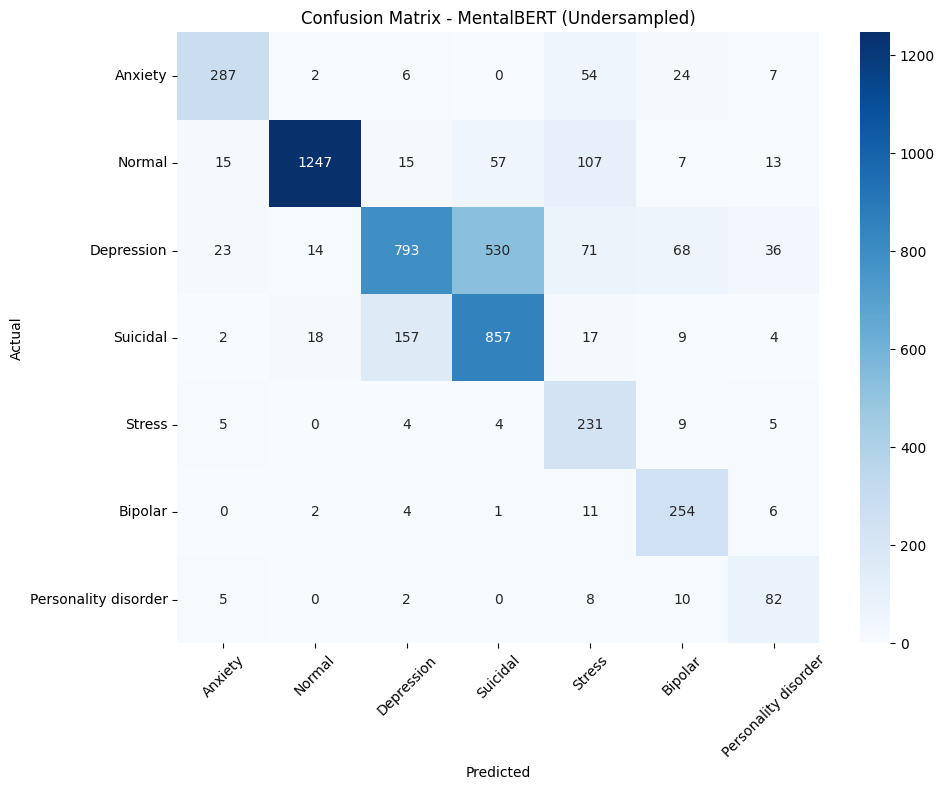

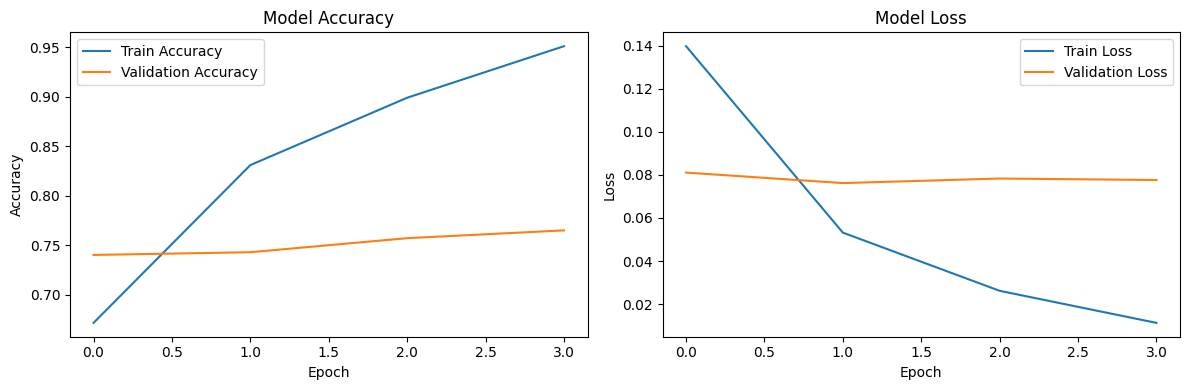

In [ ]:
cm = confusion_matrix(y_test_array, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix - MentalBERT (Undersampled)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Prediction Function

In [ ]:
def predict_mental_health(text):
    cleaned_text = clean_text_bert(text)

    encoded_input = tokenizer(
        cleaned_text, return_tensors='tf', truncation=True, padding='max_length', max_length=MAX_LEN
    )

    outputs = model(encoded_input)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()[0]

    pred_class = np.argmax(probs)
    confidence = probs[pred_class]

    print("Input Text:", text)
    print("\nPredicted Label:", reverse_label_map[pred_class])
    print(f"\nConfidence Score: {confidence:.4f}")
    print("="*50)

print("\n--- TEST PREDICTION ---")
predict_mental_health("I feel hopeless and empty. I don't want to live anymore.")
predict_mental_health("I am very happy today and excited to meet my friends.")
predict_mental_health("My heart is racing and I am terrified to go outside.")


--- TEST PREDICTION ---
Input Text: I feel hopeless and empty. I don't want to live anymore.

Predicted Label: Depression

Confidence Score: 0.3259
Input Text: I am very happy today and excited to meet my friends.

Predicted Label: Normal

Confidence Score: 0.8705
Input Text: My heart is racing and I am terrified to go outside.

Predicted Label: Anxiety

Confidence Score: 0.3232


# Save Model

In [ ]:
import os
SAVE_PATH = "./mentalbert_mental_health_model"
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("\nModel & Tokenizer Saved Successfully to:", SAVE_PATH)


Model & Tokenizer Saved Successfully to: ./mentalbert_mental_health_model


# Model 1: Baseline LSTM + Smoothed Class Weight

# Install and Environment Setup

In [ ]:
!pip install tensorflow -q
!pip install imbalanced-learn -q
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version : 2.20.0
GPU Available      : 1


# Load Dataset and Data Cleaning

In [ ]:
df = pd.read_csv('mental_health.csv')
df = df[['statement', 'status']]
df.reset_index(drop=True, inplace=True)
df.dropna(inplace=True)

def clean_text_lstm(text):
    text = str(text).lower()
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[\n\r]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['processed_text'] = df['statement'].apply(clean_text_lstm)

df = df[df['processed_text'].str.split().str.len() > 3]
df = df.reset_index(drop=True)

# Label Encoding

In [ ]:
label_map = {k:i for i,k in enumerate(df['status'].unique())}
reverse_label_map = {v: k for k, v in label_map.items()}
num_classes = len(label_map)

df['label'] = df['status'].map(label_map)
print("\nLabel Map:", label_map)


Label Map: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}


# Data Split

In [ ]:
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    df['processed_text'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

X_valid_raw, X_test_raw, y_valid_raw, y_test_raw = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Smoothed Class Weight (Handling Class Imbalance)

In [ ]:
print("\nCalculating Smoothed Class Weights...")
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)

class_weights_dict = {k: np.sqrt(v) for k, v in enumerate(weights)}

print("Smoothed Class Weights:")
for k, v in class_weights_dict.items():
    print(f"Class {k} ({reverse_label_map[k]}): {v:.4f}")


Calculating Smoothed Class Weights...
Smoothed Class Weights:
Class 0 (Anxiety): 1.3847
Class 1 (Normal): 0.7037
Class 2 (Depression): 0.6882
Class 3 (Suicidal): 0.8269
Class 4 (Stress): 1.6789
Class 5 (Bipolar): 1.6177
Class 6 (Personality disorder): 2.5973


# Tokenization for Model LSTM

In [ ]:
MAX_VOCAB = 10000
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 10

print("\nTokenizing Text Data...")
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post')
X_valid_seq = pad_sequences(tokenizer.texts_to_sequences(X_valid_raw), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LEN, padding='post')


Tokenizing Text Data...


# Custom Focal Loss Class

In [ ]:
class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes, gamma=2.0, alpha=0.25, from_logits=False):
        super().__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_onehot = tf.one_hot(y_true, depth=self.num_classes)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1 - y_pred, self.gamma)
        loss = weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

# Build LSTM Model

In [ ]:
print("\nBuilding LSTM Model...")
model_lstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

focal_loss = SparseCategoricalFocalLoss(num_classes=num_classes, gamma=2.0, alpha=0.25, from_logits=False)

model_lstm.compile(optimizer='adam', loss=focal_loss, metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1)


Building LSTM Model...


# Training

In [ ]:
print("\nStarting Training Model 1 (LSTM)...\n")
history_lstm = model_lstm.fit(
    X_train_seq, y_train_raw,
    validation_data=(X_valid_seq, y_valid_raw),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)


Starting Training Model 1 (LSTM)...

Epoch 1/10
1273/1273 [==============================] - 730s 568ms/step - loss: 0.1347 - accuracy: 0.5832 - val_loss: 0.1092 - val_accuracy: 0.6649 - lr: 0.0010
Epoch 2/10
1273/1273 [==============================] - 696s 547ms/step - loss: 0.0904 - accuracy: 0.6905 - val_loss: 0.0971 - val_accuracy: 0.6861 - lr: 0.0010
Epoch 3/10
1273/1273 [==============================] - 675s 530ms/step - loss: 0.0708 - accuracy: 0.7386 - val_loss: 0.0904 - val_accuracy: 0.7127 - lr: 0.0010
Epoch 4/10
1273/1273 [==============================] - 676s 531ms/step - loss: 0.0575 - accuracy: 0.7753 - val_loss: 0.0887 - val_accuracy: 0.7209 - lr: 0.0010
Epoch 5/10
1273/1273 [==============================] - ETA: 0s - loss: 0.0491 - accuracy: 0.7960
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1273/1273 [==============================] - 663s 521ms/step - loss: 0.0491 - accuracy: 0.7960 - val_loss: 0.0912 - val_accuracy: 0.7313 - lr: 0

# Evaluasi Model 1


Evaluating Model...

160/160 [==============================] - 9s 55ms/step

Model 1 Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.75      0.77      0.76       379
              Normal       0.88      0.93      0.90      1468
          Depression       0.72      0.55      0.62      1535
            Suicidal       0.60      0.77      0.67      1064
              Stress       0.50      0.49      0.50       258
             Bipolar       0.78      0.63      0.70       278
Personality disorder       0.40      0.46      0.43       107

            accuracy                           0.72      5089
           macro avg       0.66      0.66      0.65      5089
        weighted avg       0.73      0.72      0.72      5089



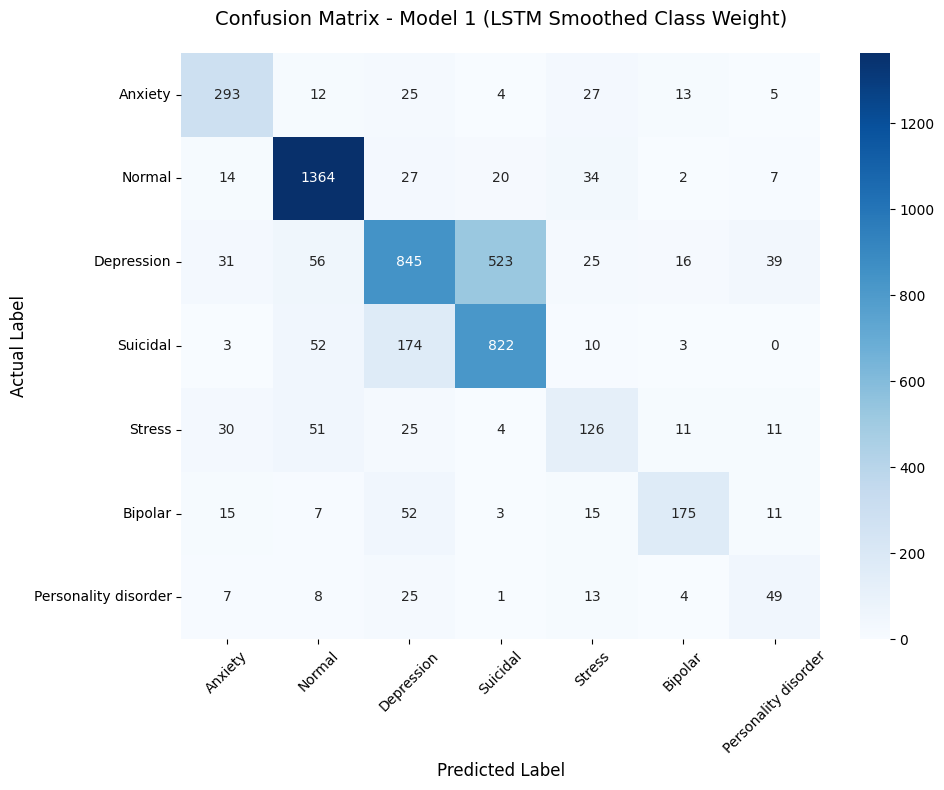

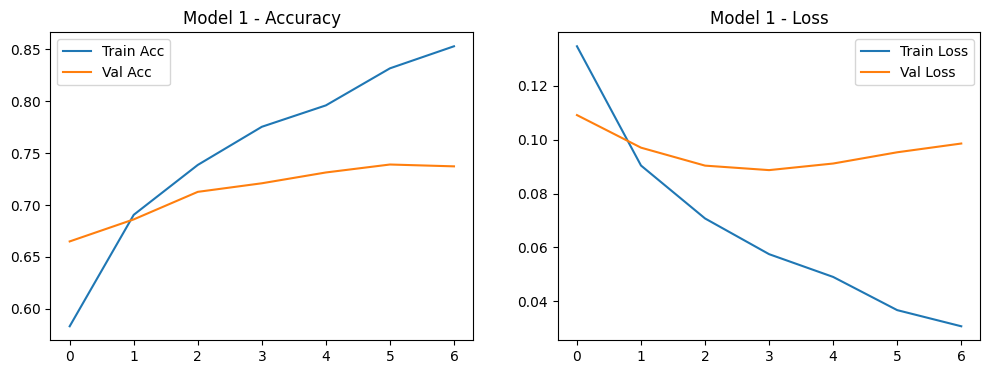

In [ ]:
print("\nEvaluating Model...\n")
y_pred1_probs = model_lstm.predict(X_test_seq)
y_pred1 = np.argmax(y_pred1_probs, axis=1)

print("\nModel 1 Classification Report:\n")
print(classification_report(y_test_raw, y_pred1, target_names=label_map.keys()))

cm1 = confusion_matrix(y_test_raw, y_pred1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_map.keys(),
    yticklabels=label_map.keys()
)

plt.title('Confusion Matrix - Model 1 (LSTM Smoothed Class Weight)', pad=20, fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.title("Model 1 - Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("Model 1 - Loss")
plt.legend()
plt.show()

# Predict Function

In [ ]:
def predict_model_1(text):
    text_processed = clean_text_lstm(text)
    seq = tokenizer.texts_to_sequences([text_processed])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    pred = model_lstm.predict(pad, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    print("\n" + "="*50)
    print("Input Text      :", text)
    print("Predicted Label :", reverse_label_map[pred_class])
    print(f"Confidence Score: {confidence:.4f}")
    print("="*50)

print("\n--- Uji Coba Prediksi Model 1 ---")
predict_model_1("I feel empty and hopeless everyday")
predict_model_1("Today I am happy and excited")
predict_model_1("I'm constantly worrying about the future and can't breathe")


--- Uji Coba Prediksi Model 1 ---

Input Text      : I feel empty and hopeless everyday
Predicted Label : Depression
Confidence Score: 0.5372

Input Text      : Today I am happy and excited
Predicted Label : Normal
Confidence Score: 0.9226

Input Text      : I'm constantly worrying about the future and can't breathe
Predicted Label : Anxiety
Confidence Score: 0.6027


# Save Model and ZIP

In [ ]:
import pickle
import shutil
from google.colab import files

model_lstm.save("model_lstm_smoothed_cw.h5")

with open("tokenizer_lstm_smoothed.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("\nModel 1 dan Tokenizer berhasil disimpan!")

SAVE_FOLDER_LSTM = "./lstm_mental_health_model1_final"
os.makedirs(SAVE_FOLDER_LSTM, exist_ok=True)

shutil.move("model_lstm_smoothed_cw.h5", f"{SAVE_FOLDER_LSTM}/model_lstm_smoothed_cw.h5")
shutil.move("tokenizer_lstm_smoothed.pkl", f"{SAVE_FOLDER_LSTM}/tokenizer_lstm_smoothed.pkl")

shutil.make_archive("lstm_mental_health_model1_final", 'zip', SAVE_FOLDER_LSTM)
print("Folder model telah di-zip menjadi lstm_mental_health_model1_final.zip")

files.download("lstm_mental_health_model1_final.zip")

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Model 1 dan Tokenizer berhasil disimpan!
Folder model telah di-zip menjadi lstm_mental_health_model1_final.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model 2: MentalBert + Smoothed Class Weight

# Install and Environment Setup

In [1]:
!pip uninstall -y transformers -q
!pip install transformers==4.38.2 -q
!pip install tensorflow -q
!pip install imbalanced-learn -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", len(tf.config.list_physical_devices('GPU')))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
TensorFlow Version : 2.20.0
GPU Available      : 1


# Load Dataset and Data Cleaning

In [9]:
df = pd.read_csv("mental_health.csv")
df = df[['statement', 'status']].dropna().reset_index(drop=True)

print("Dataset Shape (Original):", df.shape)

def clean_text_bert(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['processed_text'] = df['statement'].apply(clean_text_bert)

# Hapus teks yang terlalu pendek (< 4 kata) karena ambigu
df = df[df['processed_text'].str.split().str.len() > 3]
df = df.reset_index(drop=True)

Dataset Shape (Original): (52681, 2)


# Label Encoding

In [10]:
label_map = {label: idx for idx, label in enumerate(df['status'].unique())}
reverse_label_map = {idx: label for label, idx in label_map.items()}
num_classes = len(label_map)

df['label'] = df['status'].map(label_map)

print("\nLabel Mapping:")
print(label_map)


Label Mapping:
{'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}


# Train Valid Test Split

In [11]:
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

X_valid_raw, X_test_raw, y_valid_raw, y_test_raw = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("\nTrain Size :", len(X_train_raw))
print("Valid Size :", len(X_valid_raw))
print("Test Size  :", len(X_test_raw))


Train Size : 40656
Valid Size : 5082
Test Size  : 5083


# Smoothed Class Weights

In [12]:
print("\nCalculating Smoothed Class Weights...")
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)

class_weights_dict = {k: np.sqrt(v) for k, v in enumerate(weights)}

print("Smoothed Class Weights Dictionary:")
for k, v in class_weights_dict.items():
    print(f"Class {k} ({reverse_label_map[k]}): {v:.4f}")


Calculating Smoothed Class Weights...
Smoothed Class Weights Dictionary:
Class 0 (Anxiety): 1.3838
Class 1 (Normal): 0.7049
Class 2 (Depression): 0.6878
Class 3 (Suicidal): 0.8262
Class 4 (Stress): 1.6775
Class 5 (Bipolar): 1.6171
Class 6 (Personality disorder): 2.5957


# Hugging Face Login

In [ ]:
from huggingface_hub import login

login(token="_____")

# Tokenization Mental Bert

In [14]:
MODEL_NAME = "mental/mental-bert-base-uncased"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 5

print(f"\nLoading Tokenizer : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='tf'
    )

train_encodings = encode_data(X_train_raw)
valid_encodings = encode_data(X_valid_raw)
test_encodings  = encode_data(X_test_raw)


Loading Tokenizer : mental/mental-bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# TF Dataset

In [15]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask']},
    y_train_raw.values
)).shuffle(len(X_train_raw)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': valid_encodings['input_ids'], 'attention_mask': valid_encodings['attention_mask']},
    y_valid_raw.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask']},
    y_test_raw.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build Mental Bert Model

In [16]:
print(f"\nLoading Pretrained Model : {MODEL_NAME}")
model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes, from_pt=True)

model.config.hidden_dropout_prob = 0.3
model.config.attention_probs_dropout_prob = 0.3


Loading Pretrained Model : mental/mental-bert-base-uncased


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Custom Focal Loss

In [17]:
class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes, gamma=2.0, alpha=0.25, from_logits=False):
        super().__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_onehot = tf.one_hot(y_true, depth=self.num_classes)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1 - y_pred, self.gamma)
        loss = weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

# Compile and Callbacks

In [18]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

focal_loss = SparseCategoricalFocalLoss(num_classes=num_classes, gamma=2.0, alpha=0.25, from_logits=True)

model.compile(optimizer=optimizer, loss=focal_loss, metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1)

# Training

In [19]:
print("\nStarting Training...\n")
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)


Starting Training...

Epoch 1/5
5082/5082 [==============================] - 2405s 464ms/step - loss: 0.0579 - accuracy: 0.7827 - val_loss: 0.0409 - val_accuracy: 0.8308 - lr: 1.0000e-05
Epoch 2/5
5082/5082 [==============================] - 2353s 463ms/step - loss: 0.0296 - accuracy: 0.8471 - val_loss: 0.0403 - val_accuracy: 0.8327 - lr: 1.0000e-05
Epoch 3/5
5082/5082 [==============================] - ETA: 0s - loss: 0.0194 - accuracy: 0.8796
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
5082/5082 [==============================] - 2353s 463ms/step - loss: 0.0194 - accuracy: 0.8796 - val_loss: 0.0449 - val_accuracy: 0.8282 - lr: 1.0000e-05
Epoch 4/5
5082/5082 [==============================] - ETA: 0s - loss: 0.0126 - accuracy: 0.9118
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
5082/5082 [==============================] - 2353s 463ms/step - loss: 0.0126 - accuracy: 0.9118 - val_loss: 0.0432 - val_accuracy: 0.8410 - lr: 5.

# Evaluation

In [20]:
print("\nEvaluating Model...\n")
predictions = model.predict(test_dataset)

y_pred_probs = tf.nn.softmax(predictions.logits, axis=-1).numpy()
y_pred = np.argmax(y_pred_probs, axis=1)

y_test_array = y_test_raw.values

weighted_f1 = f1_score(y_test_array, y_pred, average='weighted')
macro_f1 = f1_score(y_test_array, y_pred, average='macro')

print(f"\nWeighted F1 Score : {weighted_f1:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_array, y_pred, target_names=label_map.keys()))


Evaluating Model...

636/636 [==============================] - 103s 158ms/step

Weighted F1 Score : 0.8390
Macro F1 Score    : 0.8300

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.92      0.84      0.88       380
              Normal       0.95      0.95      0.95      1461
          Depression       0.79      0.79      0.79      1535
            Suicidal       0.74      0.77      0.75      1064
              Stress       0.78      0.76      0.77       258
             Bipolar       0.92      0.83      0.87       278
Personality disorder       0.74      0.86      0.79       107

            accuracy                           0.84      5083
           macro avg       0.83      0.83      0.83      5083
        weighted avg       0.84      0.84      0.84      5083



# Confusion Matrix and Visualization

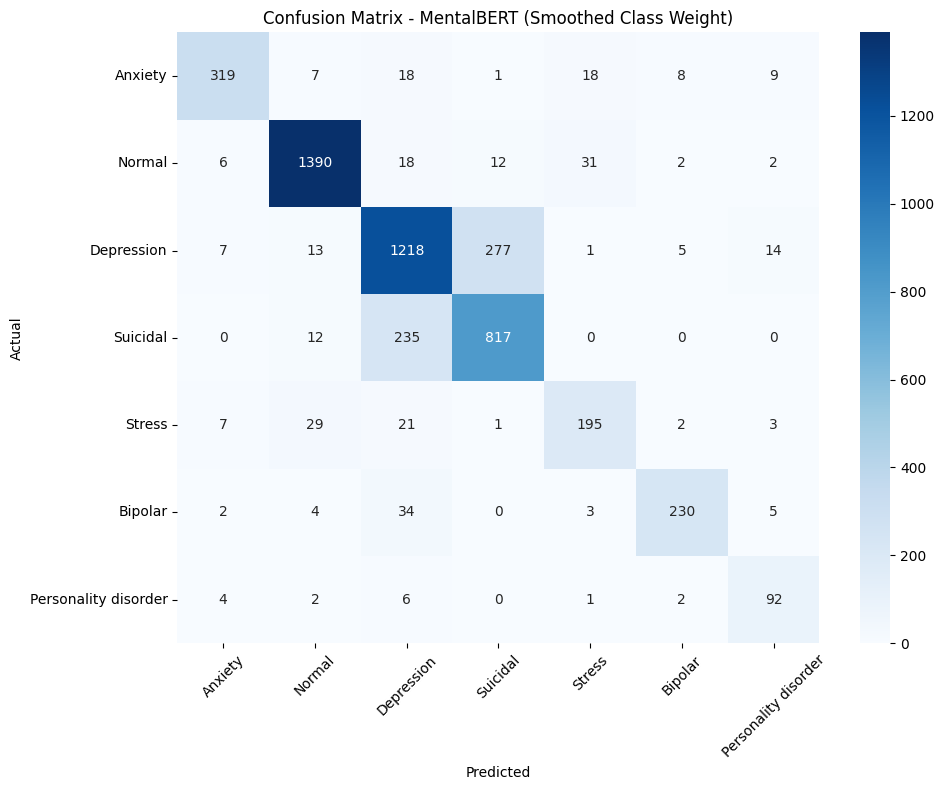

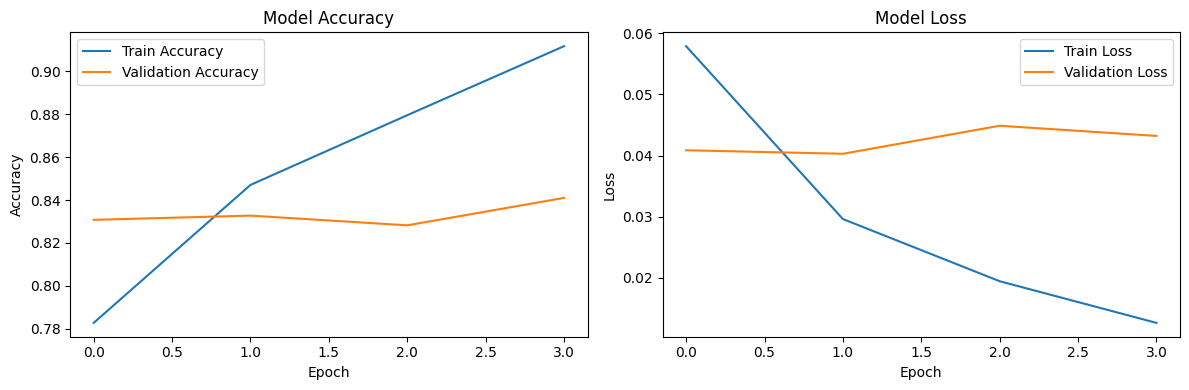

In [21]:
cm = confusion_matrix(y_test_array, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix - MentalBERT (Smoothed Class Weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Predict Function

In [22]:
def predict_mental_health(text):
    cleaned_text = clean_text_bert(text)

    encoded_input = tokenizer(
        cleaned_text, return_tensors='tf', truncation=True, padding='max_length', max_length=MAX_LEN
    )

    outputs = model(encoded_input)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()[0]

    pred_class = np.argmax(probs)
    confidence = probs[pred_class]

    print("\n" + "="*50)
    print("Input Text:", text)
    print("\nPredicted Label:", reverse_label_map[pred_class])
    print(f"\nConfidence Score: {confidence:.4f}")
    print("="*50)

print("\n--- TEST PREDICTION ---")
predict_mental_health("I feel hopeless and empty. I don't want to live anymore.")
predict_mental_health("I am very happy today and excited to meet my friends.")
predict_mental_health("My heart is racing and I am terrified to go outside.")


--- TEST PREDICTION ---

Input Text: I feel hopeless and empty. I don't want to live anymore.

Predicted Label: Depression

Confidence Score: 0.5576

Input Text: I am very happy today and excited to meet my friends.

Predicted Label: Normal

Confidence Score: 0.6750

Input Text: My heart is racing and I am terrified to go outside.

Predicted Label: Anxiety

Confidence Score: 0.3756


In [23]:
import os
SAVE_PATH = "./mentalbert_mental_health_model2_final"
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("\nModel & Tokenizer Saved Successfully to:", SAVE_PATH)


Model & Tokenizer Saved Successfully to: ./mentalbert_mental_health_model2_final


In [24]:
import shutil
from google.colab import files

shutil.make_archive("mentalbert_mental_health_model2_final", 'zip', SAVE_PATH)
print("Folder model telah di-zip menjadi mentalbert_saved_model.zip")

files.download("mentalbert_mental_health_model2_final.zip")

Folder model telah di-zip menjadi mentalbert_saved_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>